In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install tensorflow-text

In [ ]:
pip install sentencepiece

In [ ]:
!pip install pytorch-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split


from transformers import XLNetModel, XLNetTokenizer, XLNetForSequenceClassification
from torch.optim import AdamW

from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import tensorflow as tf
import tensorflow_text as tf_text
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns  # Import seaborn for visualization


device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))


Found GPU at: /device:GPU:0


In [ ]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
torch.cuda.get_device_name(0)

'Tesla T4'

In [ ]:
df = pd.read_csv("/content/Dataset Cyberbullying Media Sosial.csv")

In [ ]:
df

,Text,Label,CaseFold,RegRemoval,SymbolsRemoval
0,Oooo statusnya masih darurat tho?... Daruratny...,0,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...
1,Pembicaraan antar profesor pas mengemukakan pe...,1,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...
2,nonton cuma liat timecode berjalan...soalnya k...,1,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...
3,Kura kura Galapagos dan ikan laut dalam palung...,1,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...
4,Podcast 3 makhluk ghoib.,1,podcast 3 makhluk ghoib.,podcast makhluk ghoib.,podcast makhluk ghoib.
...,...,...,...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66632,Repost @kompascom (Berita selengkapnya klik IG...,0,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...


In [ ]:
df.drop(["CaseFold", "RegRemoval", "SymbolsRemoval"],axis=1,inplace=True)

In [ ]:
df

,Text,Label
0,Oooo statusnya masih darurat tho?... Daruratny...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalan...soalnya k...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib.,1
...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66632,Repost @kompascom (Berita selengkapnya klik IG...,0
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0


In [ ]:
df.isna().sum()

,0
Text,0
Label,0


In [ ]:
df['Text'] = df['Text'].str.replace('[^a-zA-Z0-9\s]+', '', regex=True)
df

,Text,Label
0,Oooo statusnya masih darurat tho Daruratnya di...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalansoalnya kaga...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib,1
...,...,...
66630,Istinysaq Memasukkan air dalam hidung serta Is...,0
66631,Istinysaq Memasukkan air dalam hidung serta Is...,0
66632,Repost kompascom Berita selengkapnya klik IG S...,0
66633,jasaakuntansipajak Menyediakan jasa pengerjaan...,0


In [ ]:
labels = df['Label']
unique_labels = labels.unique()
unique_labels

array([0, 1])

In [ ]:
df['Label'].value_counts()

,count
Label,
0,60487
1,6148


In [ ]:
# Menggabungkan teks dan label untuk mempermudah pengolahan
data = pd.DataFrame({'Text': df['Text'], 'Label': labels})

# Memisahkan data berdasarkan label
label_0 = data[data['Label'] == 0]
label_1 = data[data['Label'] == 1]

# Undersampling ke ukuran yang sama
from sklearn.utils import resample # Import resample if it's not already imported

# Menentukan ukuran terkecil
min_size = min(len(label_0), len(label_1))

# Melakukan undersampling pada label mayoritas
label_0_undersampled = resample(label_0,
                                 replace=False, # Without replacement (no duplicates)
                                 n_samples=min_size, # Match the minority class size
                                 random_state=42) # For reproducibility

# Gabungkan kembali data yang telah di-undersample
undersampled_data = pd.concat([label_0_undersampled, label_1])

# Perbarui df dengan data yang telah di-undersample
df = undersampled_data.copy()

In [ ]:
df['Label'].value_counts()

,count
Label,
0,6148
1,6148


In [ ]:
df

,Text,Label
26489,Bucin,0
15811,Salute buat Deny cagur kuat banget,0
6602,Cheewyxizy iyaa kaka sayang semua boleh komen ...,0
32938,Fajar lu di kasih tisu itu buat lap air mata l...,0
36625,Kayanya dia butuh psikolog,0
...,...,...
66538,Ada yang kena omel TKW Indonesia nih Mbak TKW ...,1
66590,Coba makanya deh itu pegawai bea cukai produc...,1
66592,Indonesia urutan ke berapa ya Hi Monefriends...,1
66594,Rubicon nya siapa nih Lebih kaget lagi kalo li...,1


In [ ]:
import re
import string
def clean_text(text):
#    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
#    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [ ]:
df['text_clean'] = df['Text'].apply(clean_text)
df.sample(10)

,Text,Label,text_clean
17891,Cewek kenal cowok pas sukses tapi tidak pas su...,0,cewek kenal cowok pas sukses tapi tidak pas su...
2746,Bude ku meninggal gegara covid dan komplikasi ...,1,bude ku meninggal gegara covid dan komplikasi ...
18232,Fajar bucin,0,fajar bucin
26294,Kok sek onok wong kyok ngene brDikasih tisu bu...,0,kok sek onok wong kyok ngene brdikasih tisu bu...
3900,KENAPA GK BOLEH PAK ANIES BERTEMU RAKYAT APA S...,1,kenapa gk boleh pak anies bertemu rakyat apa s...
34277,Ini manusia asli seperti ini atau sengaja dibu...,0,ini manusia asli seperti ini atau sengaja dibu...
56665,Muhaimin Gi mana,0,muhaimin gi mana
3153,hdiir bng vaikky,1,hdiir bng vaikky
22989,Bang Jali sama sekali nggak ketawa padahal obr...,0,bang jali sama sekali nggak ketawa padahal obr...
65690,Pak said didu saya org sumut mendoakan spy bpk...,1,pak said didu saya org sumut mendoakan spy bpk...


In [ ]:
df['Text'] = df['text_clean'].copy()
df.sample(10)

,Text,Label,text_clean
1049,wakwaw bikin konten ngak ngapa ngapain,1,wakwaw bikin konten ngak ngapa ngapain
64619,kolaborasi yang pas,0,kolaborasi yang pas
44965,saya yakin nasibnya akan berubah derastis,0,saya yakin nasibnya akan berubah derastis
3135,insyaa allah sdhulai syutong,1,insyaa allah sdhulai syutong
38758,ms denny keren bisa tahan ngakak aku sepanjang...,0,ms denny keren bisa tahan ngakak aku sepanjang...
42967,kaya non bullyton drama dengan full kata kata ...,0,kaya non bullyton drama dengan full kata kata ...
58822,serasa masuk mythic glory point,0,serasa masuk mythic glory point
1648,anji manji sewaktu kecil,1,anji manji sewaktu kecil
395,telah kita ketahui bahwa seni adalah ledakan s...,1,telah kita ketahui bahwa seni adalah ledakan s...
50797,dia mah bersyukur garaquot di putusin cewekja...,0,dia mah bersyukur garaquot di putusin cewekja...


In [ ]:
# STOPWORDS
import nltk
#nltk.download('stopwords')
#stop_words = stopwords.words('english')
#more_stopwords = ['u', 'im', 'c']
#stop_words = stop_words + more_stopwords

#def remove_stopwords(text):
#    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
#    return text

#df['text_clean'] = df['text_clean'].apply(remove_stopwords)
#df.head()

In [ ]:
df

,Text,Label,text_clean
26489,bucin,0,bucin
15811,salute buat deny cagur kuat banget,0,salute buat deny cagur kuat banget
6602,cheewyxizy iyaa kaka sayang semua boleh komen ...,0,cheewyxizy iyaa kaka sayang semua boleh komen ...
32938,fajar lu di kasih tisu itu buat lap air mata l...,0,fajar lu di kasih tisu itu buat lap air mata l...
36625,kayanya dia butuh psikolog,0,kayanya dia butuh psikolog
...,...,...,...
66538,ada yang kena omel tkw indonesia nih mbak tkw ...,1,ada yang kena omel tkw indonesia nih mbak tkw ...
66590,coba makanya deh itu pegawai bea cukai produc...,1,coba makanya deh itu pegawai bea cukai produc...
66592,indonesia urutan ke berapa ya hi monefriends...,1,indonesia urutan ke berapa ya hi monefriends...
66594,rubicon nya siapa nih lebih kaget lagi kalo li...,1,rubicon nya siapa nih lebih kaget lagi kalo li...


In [ ]:
text = df['Text'].tolist() # Create text list from df['Text']
text = [Text + " [SEP] [CLS]" for Text in text]
label = df.Label.values

In [ ]:
#tweet = pd.DataFrame(tweet)

In [ ]:
#tweet.to_csv('tweet.csv')

In [ ]:
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased', do_lower_case=True)

tokenized_text = [tokenizer.tokenize(sent) for sent in text]
print ("Tokenize the first sentence:")
print (tokenized_text[0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

Tokenize the first sentence:
['▁', 'bu', 'cin', '▁[', 's', 'ep', ']', '▁[', 'cl', 's', ']']


In [ ]:
#tokenized_tweet = pd.DataFrame(tokenized_tweet)
#tokenized_tweet.to_csv('token.csv')

In [ ]:
# Set the maximum sequence length. The longest sequence in our training set is 47, but we'll leave room on the end anyway.
MAX_LEN = 128

In [ ]:
# Use the XLNet tokenizer to convert the tokens to their index numbers in the XLNet vocabulary
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_text]

In [ ]:
# Pad our input tokens
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [ ]:
# Create attention masks
attention_masks = []

# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

# Use train_test_split to split our data into train and testing sets for training
labels = df.Label.values # Update labels with the undersampled labels
train_inputs, test_inputs, train_labels, test_labels = train_test_split(input_ids, labels,
                                                            random_state=2018, test_size=0.2)
train_masks, test_masks, _, _ = train_test_split(attention_masks, input_ids,
                                             random_state=2018, test_size=0.2)

In [ ]:
# Convert all of our data into torch tensors, the required datatype for our model

train_inputs = torch.tensor(train_inputs)
test_inputs = torch.tensor(test_inputs)
train_labels = torch.tensor(train_labels)
test_labels = torch.tensor(test_labels)
train_masks = torch.tensor(train_masks)
test_masks = torch.tensor(test_masks)

In [ ]:
# Select a batch size for training. For fine-tuning with XLNet, the authors recommend a batch size of 32, 48, or 128. We will use 32 here to avoid memory issues.
batch_size = 64

# Create an iterator of our data with torch DataLoader. This helps save on memory during training because, unlike a for loop,
# with an iterator the entire dataset does not need to be loaded into memory

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

In [ ]:
#input_ids_tweet

In [ ]:
# Load XLNEtForSequenceClassification, the pretrained XLNet model with a single linear classification layer on top.

model = XLNetForSequenceClassification.from_pretrained("xlnet-base-cased", num_labels=2)
model.cuda()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (sequence_summary): SequenceSummary(
    (summary): Linear(in_features=768, out_features=768, bias=True)
    (activation): Tanh()
    (first_dropout): Identity()
    (last

In [ ]:
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

In [ ]:
# This variable contains all of the hyperparemeter information our training loop needs
optimizer = AdamW(optimizer_grouped_parameters,
                     lr=2e-5)

In [ ]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train loss: 0.6647105340833788
Testing Accuracy: 0.6827495421245421
Accuracy: 0.6833333333333333
Precision: 0.7111716621253406
Recall: 0.6294212218649518
F1-Score: 0.6678038379530916


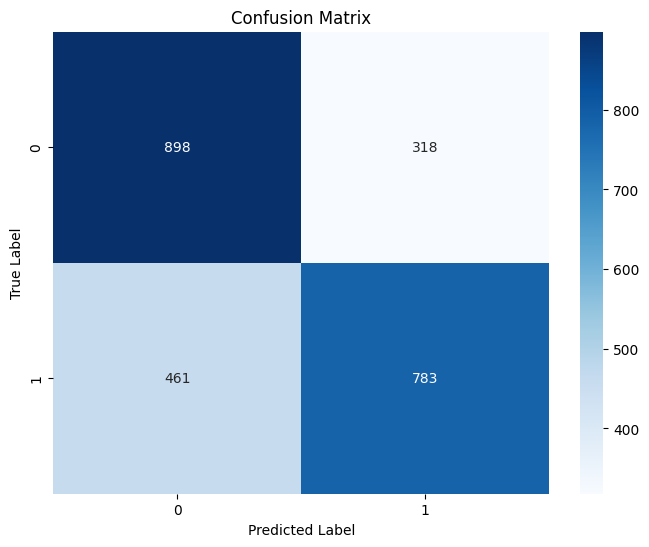

Epoch:  10%|█         | 1/10 [05:16<47:26, 316.28s/it]

Saved the best model with testing accuracy: 0.6827495421245421
Train loss: 0.5745043073381696
Testing Accuracy: 0.7106227106227107
Accuracy: 0.7105691056910569
Precision: 0.8204819277108434
Recall: 0.547427652733119
F1-Score: 0.6567020250723241


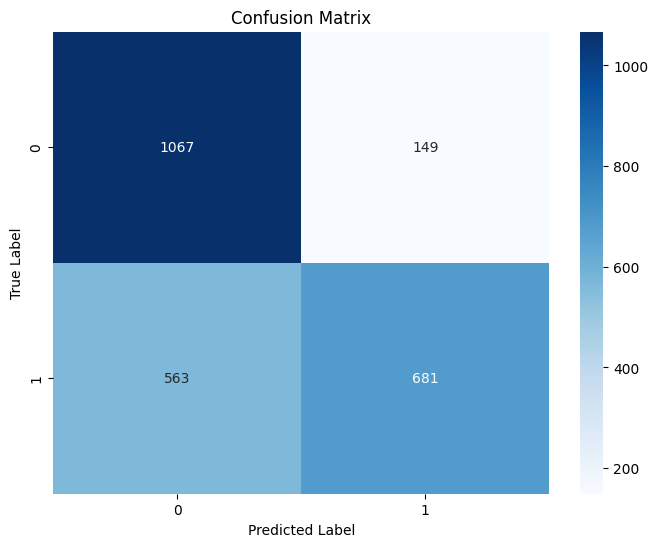

Epoch:  20%|██        | 2/10 [10:38<42:35, 319.49s/it]

Saved the best model with testing accuracy: 0.7106227106227107
Train loss: 0.5006677955389023
Testing Accuracy: 0.7536057692307693
Accuracy: 0.7536585365853659
Precision: 0.7259206798866855
Recall: 0.8239549839228296
F1-Score: 0.7718373493975903


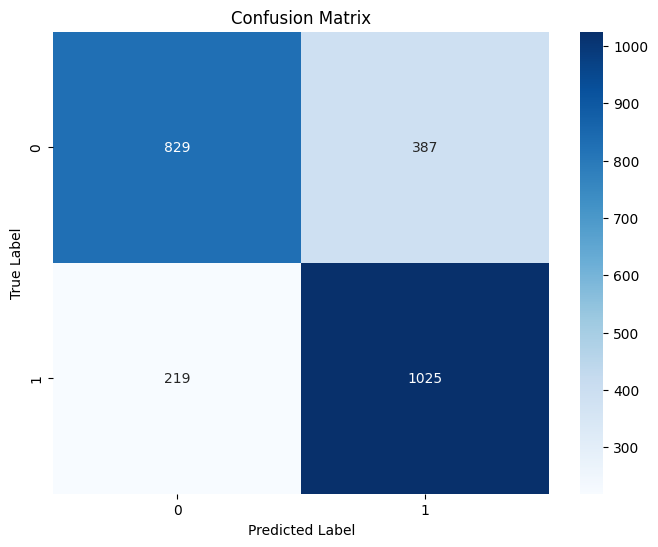

Epoch:  30%|███       | 3/10 [15:58<37:20, 320.09s/it]

Saved the best model with testing accuracy: 0.7536057692307693
Train loss: 0.4485788087953221
Testing Accuracy: 0.7616185897435898
Accuracy: 0.7617886178861789
Precision: 0.7222972972972973
Recall: 0.8593247588424437
F1-Score: 0.7848751835535976


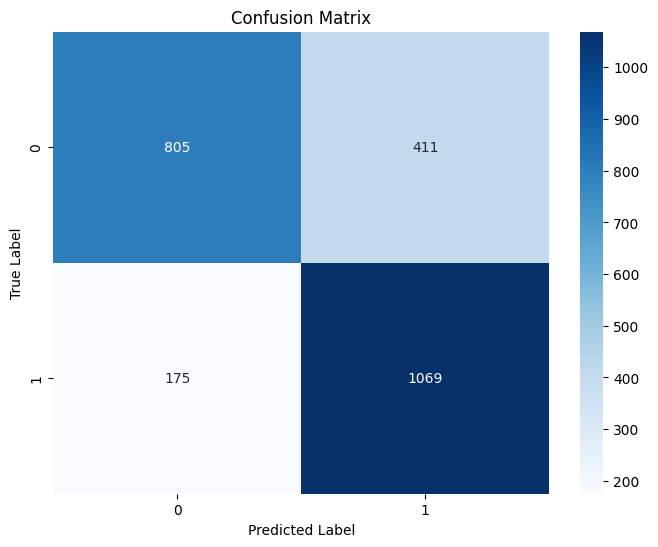

Epoch:  40%|████      | 4/10 [21:14<31:49, 318.29s/it]

Saved the best model with testing accuracy: 0.7616185897435898
Train loss: 0.4027445498224977
Testing Accuracy: 0.7509157509157509
Accuracy: 0.7504065040650406
Precision: 0.8023032629558541
Recall: 0.6720257234726688
F1-Score: 0.731408573928259


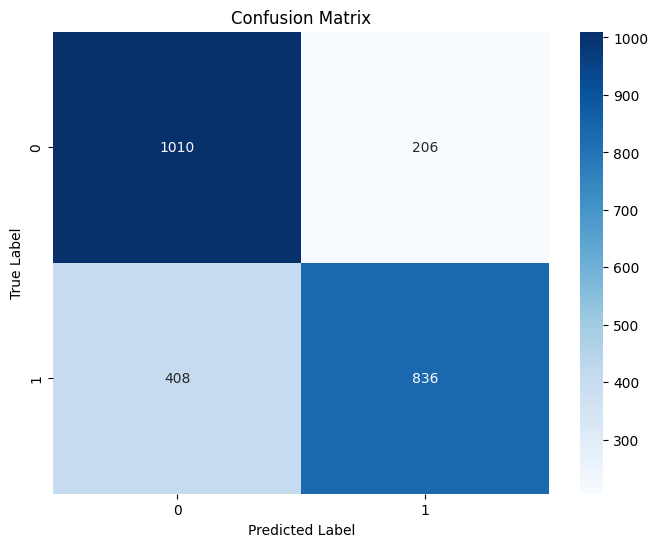

Epoch:  50%|█████     | 5/10 [26:28<26:23, 316.72s/it]

Train loss: 0.3629864678754435
Testing Accuracy: 0.7678571428571429
Accuracy: 0.7670731707317073
Precision: 0.7673306772908367
Recall: 0.7741157556270096
F1-Score: 0.7707082833133253


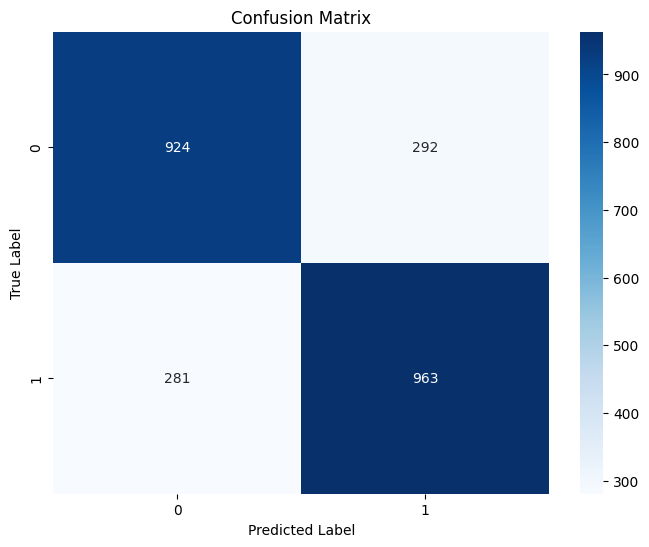

Epoch:  60%|██████    | 6/10 [31:43<21:04, 316.21s/it]

Saved the best model with testing accuracy: 0.7678571428571429
Train loss: 0.32860296819504203
Testing Accuracy: 0.7697458791208791
Accuracy: 0.7695121951219512
Precision: 0.7772317772317773
Recall: 0.7628617363344051
F1-Score: 0.7699797160243408


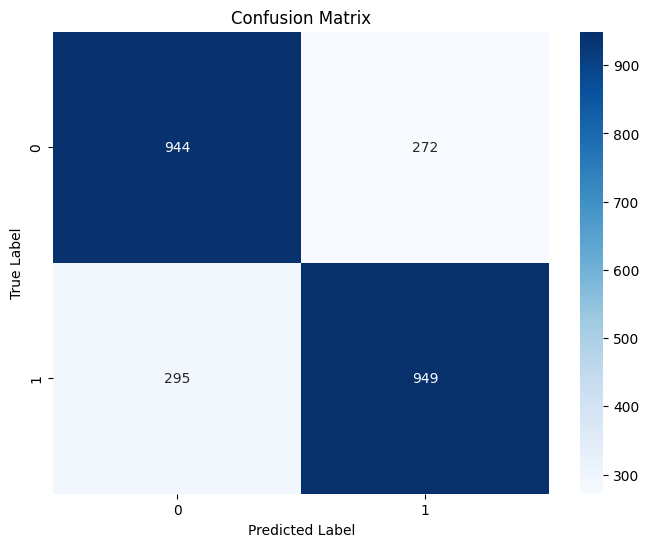

Epoch:  70%|███████   | 7/10 [36:59<15:48, 316.11s/it]

Saved the best model with testing accuracy: 0.7697458791208791
Train loss: 0.26911945002419607
Testing Accuracy: 0.7634500915750916
Accuracy: 0.7626016260162601
Precision: 0.7426470588235294
Recall: 0.8118971061093248
F1-Score: 0.7757296466973886


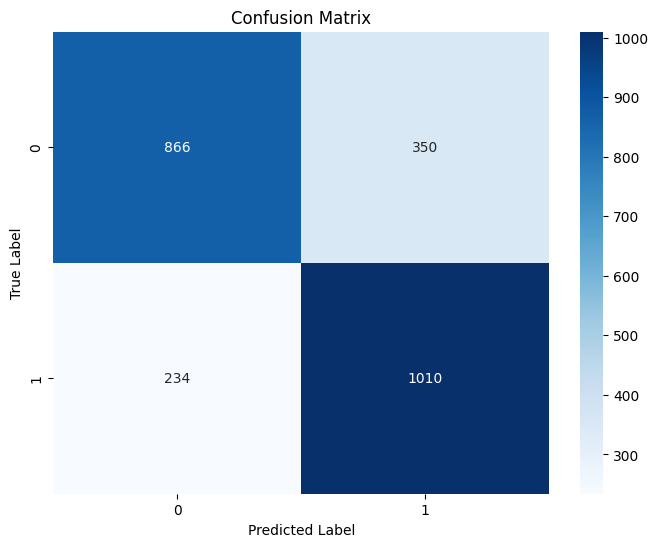

Epoch:  80%|████████  | 8/10 [42:13<10:30, 315.46s/it]

Train loss: 0.238476352741966
Testing Accuracy: 0.7557234432234432
Accuracy: 0.7552845528455284
Precision: 0.7801047120418848
Recall: 0.7186495176848875
F1-Score: 0.7481171548117155


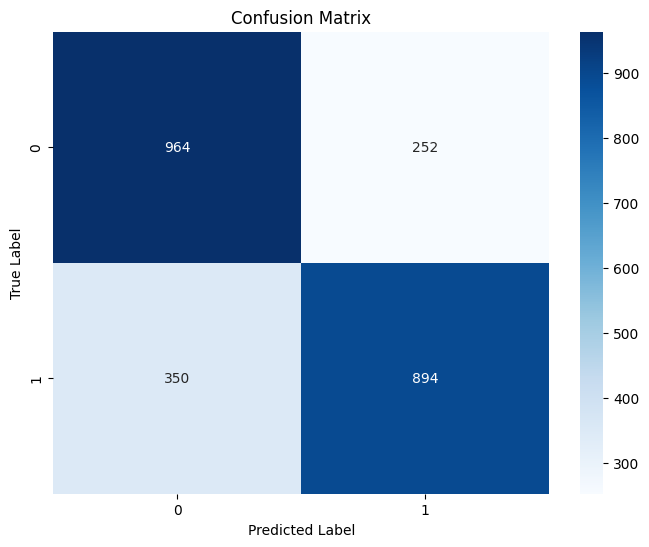

Epoch:  90%|█████████ | 9/10 [47:27<05:14, 314.92s/it]

Train loss: 0.1957025481750826
Testing Accuracy: 0.7657394688644689
Accuracy: 0.7654471544715448
Precision: 0.7696038803556993
Recall: 0.7652733118971061
F1-Score: 0.7674324869004433


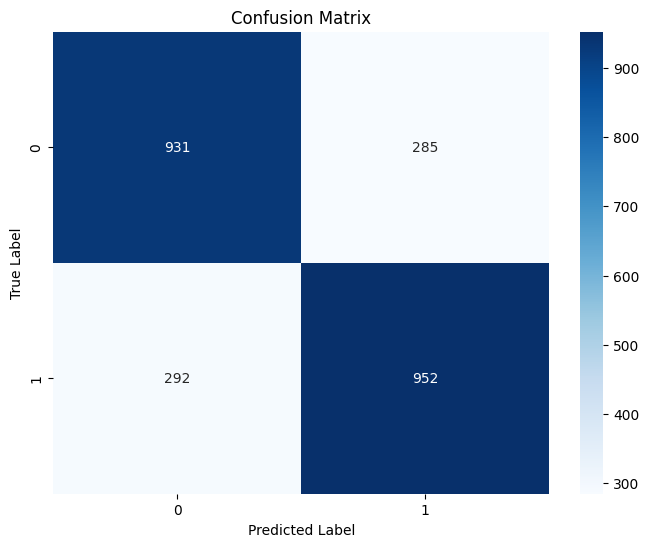

Epoch:  90%|█████████ | 9/10 [52:41<05:51, 351.25s/it]

Early stopping! No improvement for 3 consecutive epochs.


In [ ]:
# Store our loss and accuracy for plotting
train_loss_set = []

# Number of training epochs (authors recommend between 2 and 4)
epochs = 10

# Directory to save the best model
save_dir = "/content/drive/MyDrive/XLNetFix/Model"

best_epoch = 0

os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "text_model.pth")

# Initialize early stopping parameters
best_eval_accuracy = 0.0
patience = 3  # Number of epochs with no improvement after which training will be stopped
early_stopping_counter = 0

# List untuk menyimpan metrik evaluasi setiap epoch
epoch_accuracy = []
epoch_precision = []
epoch_recall = []
epoch_f1 = []
all_confusion_matrices = []

# Initialize best_cm outside the loop
best_cm = None

# trange is a tqdm wrapper around the normal python range
for _ in trange(epochs, desc="Epoch"):

  # Training

  # Set our model to training mode (as opposed to evaluation mode)
  model.train()

  # Tracking variables
  tr_loss = 0
  nb_tr_examples, nb_tr_steps = 0, 0

  # Train the data for one epoch
  for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Clear out the gradients (by default they accumulate)
    optimizer.zero_grad()
    # Forward pass
    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
    loss = outputs[0]
    logits = outputs[1]
    train_loss_set.append(loss.item())
    # Backward pass
    loss.backward()
    # Update parameters and take a step using the computed gradient
    optimizer.step()


    # Update tracking variables
    tr_loss += loss.item()
    nb_tr_examples += b_input_ids.size(0)
    nb_tr_steps += 1

  print("Train loss: {}".format(tr_loss/nb_tr_steps))


  # testing

  # Put model in evaluation mode to evaluate loss on the testing set
  model.eval()

  # Tracking variables
  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  # Store all labels and predictions for this epoch
  all_labels = []
  all_predictions = []
  all_confusion_matrices
  epoch_predictions = []


  # Evaluate data for one epoch
  for batch in test_dataloader:
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Telling the model not to compute or store gradients, saving memory and speeding up testing
    with torch.no_grad():
      # Forward pass, calculate logit predictions
      output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
      logits = output[0]

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    # Store predictions and true labels
    predictions = np.argmax(logits, axis=1).flatten()  # Get predicted labels
    epoch_predictions.extend(predictions)  # <--- Change: Append to epoch_predictions
    all_labels.extend(label_ids)  # True labels

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)

    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1

  print("Testing Accuracy: {}".format(eval_accuracy/nb_eval_steps))

  current_eval_accuracy = eval_accuracy / nb_eval_steps

  # Calculate and store evaluation metrics for the entire epoch (outside the batch loop)
  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  accuracy = accuracy_score(all_labels, epoch_predictions)
  precision = precision_score(all_labels, epoch_predictions)
  recall = recall_score(all_labels, epoch_predictions)
  f1 = 2 * (precision * recall) / (precision + recall)


  epoch_accuracy.append(accuracy)
  epoch_precision.append(precision)
  epoch_recall.append(recall)
  epoch_f1.append(f1)

  print("Accuracy: {}".format(accuracy))  # Tampilkan akurasi epoch ini
  print("Precision: {}".format(precision))  # Tampilkan presisi epoch ini
  print("Recall: {}".format(recall))  # Tampilkan recall epoch ini
  print("F1-Score: {}".format(f1))  # Tampilkan F1-score epoch ini

  # Calculate confusion matrix
  cm = confusion_matrix(all_labels, epoch_predictions)

    # Simpan confusion matrix
  all_confusion_matrices.append(cm)

  # Display confusion matrix using seaborn heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=[0, 1], yticklabels=[0, 1])  # Customize labels if needed
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix")
  plt.show()

  # Check for early stopping
  if current_eval_accuracy > best_eval_accuracy:
      best_eval_accuracy = current_eval_accuracy
      early_stopping_counter = 0
      best_epoch = _ + 1
      best_cm = cm

      # Save the best model
      torch.save(model.state_dict(), best_model_path)
      print(f"Saved the best model with testing accuracy: {best_eval_accuracy}")
  else:
      early_stopping_counter += 1

  if early_stopping_counter >= patience:
      print(f"Early stopping! No improvement for {patience} consecutive epochs.")
      break  # Stop training


Hasil Evaluasi (Epoch Terbaik):
     Metrik     Nilai  Epoch Terbaik
0   Akurasi  0.769512              7
1   Presisi  0.777232              7
2    Recall  0.762862              7
3  F1-Score  0.769980              7


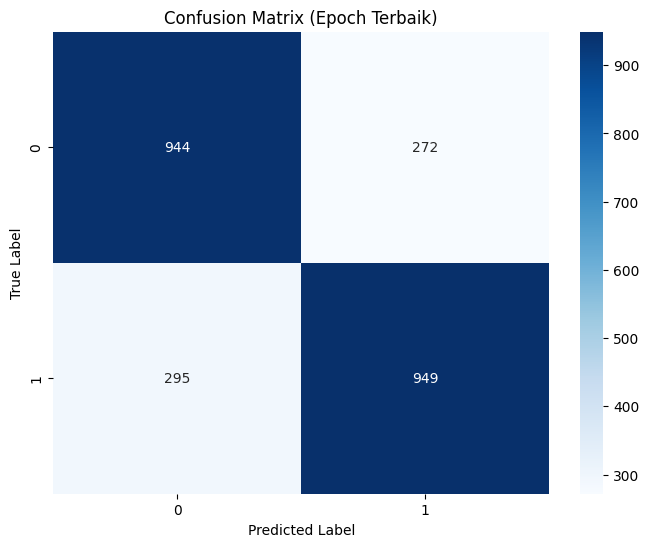

In [ ]:
data = {'Metrik': ['Akurasi', 'Presisi', 'Recall', 'F1-Score'],
        'Nilai': [epoch_accuracy[best_epoch - 1], epoch_precision[best_epoch - 1], epoch_recall[best_epoch - 1], epoch_f1[best_epoch - 1]],
        'Epoch Terbaik': [best_epoch, best_epoch, best_epoch, best_epoch]}
df_evaluasi = pd.DataFrame(data)
print("\nHasil Evaluasi (Epoch Terbaik):")
print(df_evaluasi)


# Access the confusion matrix using the valid index
best_cm

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Epoch Terbaik)")
plt.show()


Hasil Evaluasi (Epoch Terbaik):
     Metrik     Nilai  Epoch Terbaik
0   Akurasi  0.781277              2
1   Presisi  0.787346              2
2    Recall  0.767123              2
3  F1-Score  0.777103              2


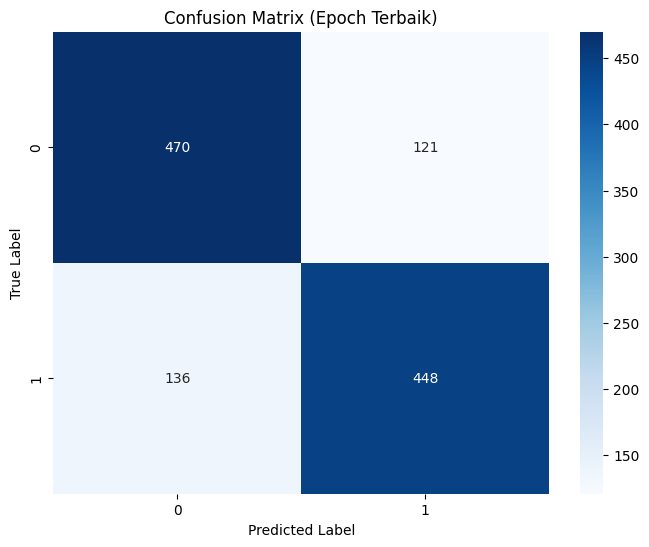

In [ ]:
data = {'Metrik': ['Akurasi', 'Presisi', 'Recall', 'F1-Score'],
        'Nilai': [epoch_accuracy[best_epoch - 1], epoch_precision[best_epoch - 1], epoch_recall[best_epoch - 1], epoch_f1[best_epoch - 1]],
        'Epoch Terbaik': [best_epoch, best_epoch, best_epoch, best_epoch]}
df_evaluasi = pd.DataFrame(data)
print("\nHasil Evaluasi (Epoch Terbaik):")
print(df_evaluasi)


# Access the confusion matrix using the valid index
best_cm

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Epoch Terbaik)")
plt.show()